# Google Trends preprocessing

Clean, rescale, stitch, and validate the manually downloaded Google Trends daily-window CSV files. Raw CSV files are read only and are not modified.

Google Trends preprocessing summary
Repository root: /Users/buithanhduy/Desktop/google_trends
Raw files found: 27 / 27
Keywords: 3
Countries: 4
Final minimum date: 2025-01-01
Final maximum date: 2026-06-30
Final rows: 6552
Expected rows: 6552
Duplicate final rows: 0
Missing final values: 0
Continuous daily coverage complete: True
Scaling factors estimated: 24 / 24
Output written: data/processed/google_trends_daily.csv
Scaling metadata written: data/processed/google_trends_scaling_factors.csv

Files with parsing warnings:
         keyword window                                                        filename  status                                                                                                                                                                           notes
             VPN    W07                          data/raw/google_trends/VPN/VPN_W07.csv WARNING multiple date columns detected; parsed country-specific date/value pairs; removed 64 out-of-window rows w

Matplotlib is building the font cache; this may take a moment.


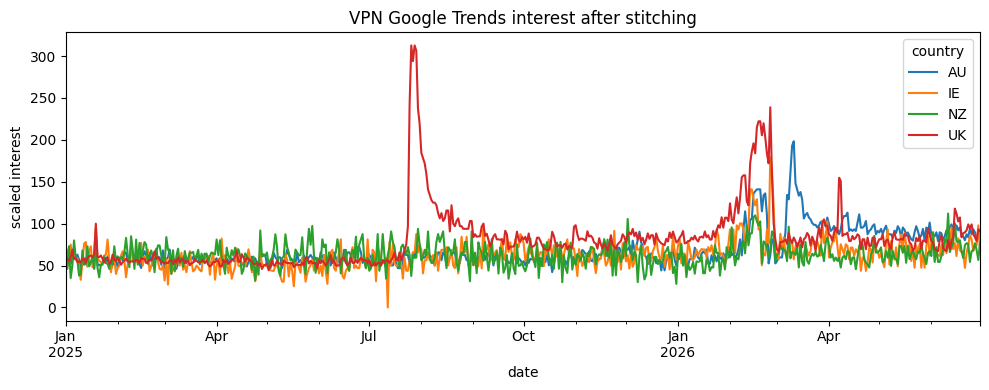

In [1]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import csv
import os
import re
import tempfile
import unicodedata

import numpy as np
import pandas as pd


COUNTRIES = ['UK', 'AU', 'IE', 'NZ']
KEYWORD_PREFIXES = {
    'VPN': 'VPN',
    'free VPN': 'freeVPN',
    'age verification': 'ageVerification',
}
WINDOWS = {
    'W01': ('2025-01-01', '2025-03-31'),
    'W02': ('2025-03-01', '2025-05-31'),
    'W03': ('2025-05-01', '2025-07-31'),
    'W04': ('2025-07-01', '2025-09-30'),
    'W05': ('2025-09-01', '2025-11-30'),
    'W06': ('2025-11-01', '2026-01-31'),
    'W07': ('2026-01-01', '2026-03-31'),
    'W08': ('2026-03-01', '2026-05-31'),
    'W09': ('2026-05-01', '2026-06-30'),
}
STUDY_START = pd.Timestamp('2025-01-01')
STUDY_END = pd.Timestamp('2026-06-30')
MIN_POSITIVE_OVERLAP_PAIRS = 10


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root from current working directory.')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
RAW_SEARCH_ROOT = REPO_ROOT / 'data'
PROCESSED_DIR = REPO_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)


def normalize_text(value: object) -> str:
    text = '' if value is None else str(value)
    text = text.replace('\ufeff', '').strip().lower()
    text = unicodedata.normalize('NFKD', text)
    text = ''.join(ch for ch in text if not unicodedata.combining(ch))
    return re.sub(r'\s+', ' ', text)


def is_date_header(value: object) -> bool:
    text = normalize_text(value)
    return text in {'ngay', 'day', 'date', 'week'}


def identify_country(value: object) -> str | None:
    text = normalize_text(value)
    if 'new zealand' in text or re.search(r'\bnz\b', text):
        return 'NZ'
    if 'united kingdom' in text or 'vuong quoc anh' in text or re.search(r'\buk\b', text):
        return 'UK'
    if 'australia' in text or re.search(r'(^|[^a-z])uc([^a-z]|$)', text) or re.search(r'\bau\b', text):
        return 'AU'
    if 'ireland' in text or re.search(r'\bie\b', text):
        return 'IE'
    return None


def read_csv_rows(path: Path) -> tuple[list[list[str]], str]:
    for encoding in ('utf-8-sig', 'utf-8'):
        try:
            with path.open('r', encoding=encoding, newline='') as handle:
                return list(csv.reader(handle)), encoding
        except UnicodeDecodeError:
            continue
    raise UnicodeDecodeError('utf-8', b'', 0, 1, f'Could not decode {path}')


def find_header_row(rows: list[list[str]]) -> tuple[int, list[str]]:
    for row_number, row in enumerate(rows):
        if not row or all(not str(cell).strip() for cell in row):
            continue
        date_headers = sum(is_date_header(cell) for cell in row)
        country_headers = sum(identify_country(cell) is not None for cell in row)
        if date_headers >= 1 and country_headers >= 4:
            return row_number, row
    raise ValueError('No data header row with a date field and four country series was found.')


def nearest_date_column(value_column: int, date_columns: list[int]) -> int:
    preceding = [column for column in date_columns if column < value_column]
    return preceding[-1] if preceding else date_columns[0]


def get_cell(row: list[str], index: int) -> str:
    return row[index].strip() if index < len(row) else ''


def parse_trend_values(values: list[str]) -> pd.Series:
    parsed = []
    for value in values:
        text = '' if value is None else str(value).strip()
        if text == '':
            parsed.append(np.nan)
        elif text.startswith('<'):
            parsed.append(0.5)
        else:
            parsed.append(pd.to_numeric(text.replace('%', '').replace(',', ''), errors='coerce'))
    return pd.Series(parsed, dtype='float64')


def expected_filename(keyword: str, window: str) -> str:
    return f'{KEYWORD_PREFIXES[keyword]}_{window}.csv'


def discover_raw_files() -> tuple[dict[tuple[str, str], Path], list[str], list[str], list[Path]]:
    all_csv = [
        path
        for path in RAW_SEARCH_ROOT.rglob('*.csv')
        if '.venv' not in path.parts and 'processed' not in path.parts
    ]
    found: dict[tuple[str, str], Path] = {}
    missing: list[str] = []
    duplicates: list[str] = []
    expected_names = set()
    for keyword in KEYWORD_PREFIXES:
        for window in WINDOWS:
            filename = expected_filename(keyword, window)
            expected_names.add(filename)
            matches = [path for path in all_csv if path.name == filename]
            if len(matches) == 1:
                found[(keyword, window)] = matches[0]
            elif len(matches) == 0:
                missing.append(filename)
            else:
                duplicates.append(f'{filename}: ' + '; '.join(str(path.relative_to(REPO_ROOT)) for path in matches))
    unexpected = [path for path in all_csv if path.name not in expected_names]
    return found, missing, duplicates, unexpected


def load_raw_window(path: Path, keyword: str, window: str) -> tuple[pd.DataFrame, dict[str, object]]:
    expected_start, expected_end = [pd.Timestamp(value) for value in WINDOWS[window]]
    expected_dates = pd.date_range(expected_start, expected_end, freq='D')
    notes: list[str] = []
    try:
        rows, encoding = read_csv_rows(path)
        header_index, header = find_header_row(rows)
    except Exception as exc:
        return pd.DataFrame(), {
            'keyword': keyword,
            'window': window,
            'filename': str(path.relative_to(REPO_ROOT)),
            'status': 'FAIL',
            'notes': f'unreadable file: {exc}',
        }

    data_rows = rows[header_index + 1:]
    date_columns = [index for index, column in enumerate(header) if is_date_header(column)]
    value_columns_by_country: dict[str, list[int]] = defaultdict(list)
    for index, column in enumerate(header):
        country = identify_country(column)
        if country is not None:
            value_columns_by_country[country].append(index)

    if len(date_columns) > 1:
        notes.append('multiple date columns detected; parsed country-specific date/value pairs')

    missing_countries = [country for country in COUNTRIES if not value_columns_by_country.get(country)]
    duplicate_country_columns = {
        country: len(columns)
        for country, columns in value_columns_by_country.items()
        if len(columns) > 1
    }

    long_parts: list[pd.DataFrame] = []
    exact_duplicate_rows_removed = 0
    out_of_window_rows_removed = 0
    for country in COUNTRIES:
        columns = value_columns_by_country.get(country, [])
        if len(columns) != 1:
            continue
        value_column = columns[0]
        date_column = nearest_date_column(value_column, date_columns)
        raw_dates = [get_cell(row, date_column) for row in data_rows]
        raw_values = [get_cell(row, value_column) for row in data_rows]
        country_frame = pd.DataFrame({
            'date': pd.to_datetime(raw_dates, errors='coerce'),
            'country': country,
            'interest_raw': parse_trend_values(raw_values),
        })
        country_frame['keyword'] = keyword
        country_frame['window'] = window
        country_frame = country_frame.dropna(subset=['date'])
        exact_duplicate_rows_removed += int(country_frame.duplicated(['date', 'country', 'interest_raw']).sum())
        country_frame = country_frame.drop_duplicates(['date', 'country', 'interest_raw'])
        in_expected_window = country_frame['date'].between(expected_start, expected_end)
        out_of_window_rows_removed += int((~in_expected_window).sum())
        country_frame = country_frame.loc[in_expected_window]
        long_parts.append(country_frame)

    if out_of_window_rows_removed:
        notes.append(f'removed {out_of_window_rows_removed} out-of-window rows while extracting expected daily slice')
    if exact_duplicate_rows_removed:
        notes.append(f'removed {exact_duplicate_rows_removed} exact duplicate rows')
    if missing_countries:
        notes.append('missing country columns: ' + ', '.join(missing_countries))
    if duplicate_country_columns:
        notes.append('duplicated country value columns: ' + str(duplicate_country_columns))

    long_df = pd.concat(long_parts, ignore_index=True) if long_parts else pd.DataFrame()
    if not long_df.empty:
        duplicate_country_dates = int(long_df.duplicated(['date', 'country'], keep=False).sum())
        if duplicate_country_dates:
            notes.append(f'averaged {duplicate_country_dates} duplicate date-country observations after filtering')
            long_df = (
                long_df.groupby(['date', 'country', 'keyword', 'window'], as_index=False)['interest_raw']
                .mean()
            )
    else:
        duplicate_country_dates = 0

    missing_dates_by_country: dict[str, int] = {}
    duplicate_dates_by_country: dict[str, int] = {}
    country_ranges_ok = True
    daily_granularity_ok = True
    zero_pct_by_country: dict[str, float] = {}
    for country in COUNTRIES:
        country_df = long_df.loc[long_df['country'] == country].sort_values('date') if not long_df.empty else pd.DataFrame()
        dates = pd.DatetimeIndex(country_df['date'].dropna().drop_duplicates()) if not country_df.empty else pd.DatetimeIndex([])
        missing_dates = expected_dates.difference(dates)
        missing_dates_by_country[country] = len(missing_dates)
        duplicate_dates_by_country[country] = int(country_df.duplicated('date').sum()) if not country_df.empty else 0
        if len(dates) != len(expected_dates) or (len(dates) and (dates.min() != expected_start or dates.max() != expected_end)):
            country_ranges_ok = False
        if len(dates) > 1 and not (pd.Series(dates).diff().dropna().dt.days == 1).all():
            daily_granularity_ok = False
        zero_pct_by_country[country] = float((country_df['interest_raw'] == 0).mean() * 100) if not country_df.empty else np.nan

    non_numeric_values = int(long_df['interest_raw'].isna().sum()) if not long_df.empty else 0
    out_of_range_values = int((long_df['interest_raw'].dropna().lt(0) | long_df['interest_raw'].dropna().gt(100)).sum()) if not long_df.empty else 0
    structural_failure = any([
        bool(missing_countries),
        bool(duplicate_country_columns),
        not country_ranges_ok,
        not daily_granularity_ok,
        non_numeric_values > 0,
        out_of_range_values > 0,
        any(value > 0 for value in missing_dates_by_country.values()),
        any(value > 0 for value in duplicate_dates_by_country.values()),
    ])
    status = 'FAIL' if structural_failure else ('WARNING' if notes else 'PASS')

    audit = {
        'keyword': keyword,
        'window': window,
        'filename': str(path.relative_to(REPO_ROOT)),
        'encoding': encoding,
        'header_row_1_based': header_index + 1,
        'raw_data_rows_after_header': len(data_rows),
        'expected_start': expected_start.date().isoformat(),
        'expected_end': expected_end.date().isoformat(),
        'actual_start': long_df['date'].min().date().isoformat() if not long_df.empty else None,
        'actual_end': long_df['date'].max().date().isoformat() if not long_df.empty else None,
        'row_count_long': len(long_df),
        'expected_row_count_long': len(expected_dates) * len(COUNTRIES),
        'daily_granularity_ok': daily_granularity_ok,
        'country_ranges_ok': country_ranges_ok,
        'missing_dates_total': sum(missing_dates_by_country.values()),
        'duplicate_dates_total': sum(duplicate_dates_by_country.values()),
        'non_numeric_values': non_numeric_values,
        'out_of_range_values': out_of_range_values,
        'out_of_window_rows_removed': out_of_window_rows_removed,
        'multiple_date_columns': len(date_columns) > 1,
        'status': status,
        'notes': '; '.join(notes) if notes else '',
    }
    for country in COUNTRIES:
        audit[f'{country.lower()}_present'] = country not in missing_countries
        audit[f'{country.lower()}_missing_dates'] = missing_dates_by_country[country]
        audit[f'{country.lower()}_zero_pct'] = zero_pct_by_country[country]
    return long_df, audit


raw_files, missing_files, duplicate_files, unexpected_csvs = discover_raw_files()
if missing_files or duplicate_files:
    raise RuntimeError(f'Missing files: {missing_files}; duplicate files: {duplicate_files}')

loaded_frames: list[pd.DataFrame] = []
audit_rows: list[dict[str, object]] = []
for keyword in KEYWORD_PREFIXES:
    for window in WINDOWS:
        frame, audit = load_raw_window(raw_files[(keyword, window)], keyword, window)
        loaded_frames.append(frame)
        audit_rows.append(audit)

raw_long = pd.concat(loaded_frames, ignore_index=True)
audit_df = pd.DataFrame(audit_rows).sort_values(['keyword', 'window']).reset_index(drop=True)
failed_files = audit_df.loc[audit_df['status'] == 'FAIL']
if not failed_files.empty:
    raise RuntimeError('Structural failures in raw files:\n' + failed_files[['keyword', 'window', 'filename', 'notes']].to_string(index=False))


def scale_keyword_windows(keyword: str, keyword_long: pd.DataFrame) -> tuple[pd.DataFrame, list[dict[str, object]], list[str]]:
    scaled_windows: dict[str, pd.DataFrame] = {}
    scaling_rows: list[dict[str, object]] = []
    scaling_warnings: list[str] = []
    first_window = 'W01'
    first = keyword_long.loc[keyword_long['window'] == first_window].copy()
    first['interest_scaled'] = first['interest_raw']
    first['scaling_factor_applied'] = 1.0
    scaled_windows[first_window] = first

    ordered_windows = list(WINDOWS.keys())
    for previous_window, current_window in zip(ordered_windows[:-1], ordered_windows[1:]):
        previous = scaled_windows[previous_window][['date', 'country', 'interest_scaled']]
        current = keyword_long.loc[keyword_long['window'] == current_window].copy()
        overlap = previous.merge(
            current[['date', 'country', 'interest_raw']],
            on=['date', 'country'],
            how='inner',
        )
        valid_overlap = overlap.loc[(overlap['interest_scaled'] > 0) & (overlap['interest_raw'] > 0)].copy()
        valid_overlap_pairs = len(valid_overlap)
        if valid_overlap_pairs == 0:
            warning = (
                f'{keyword} {previous_window}->{current_window}: no positive overlap pairs; '
                'scaling factor set to NaN'
            )
            scaling_warnings.append(warning)
            scaling_factor = np.nan
        else:
            ratios = valid_overlap['interest_scaled'] / valid_overlap['interest_raw']
            scaling_factor = float(ratios.median())
            if valid_overlap_pairs < MIN_POSITIVE_OVERLAP_PAIRS:
                scaling_warnings.append(
                    f'{keyword} {previous_window}->{current_window}: only {valid_overlap_pairs} positive overlap pairs; '
                    'used median ratio but treat this factor as fragile'
                )
        overlap_dates = pd.DatetimeIndex(overlap['date'].drop_duplicates().sort_values())
        scaling_rows.append({
            'keyword': keyword,
            'previous_window': previous_window,
            'current_window': current_window,
            'overlap_start': overlap_dates.min().date().isoformat() if len(overlap_dates) else None,
            'overlap_end': overlap_dates.max().date().isoformat() if len(overlap_dates) else None,
            'valid_overlap_pairs': valid_overlap_pairs,
            'scaling_factor': scaling_factor,
        })
        current['interest_scaled'] = current['interest_raw'] * scaling_factor
        current['scaling_factor_applied'] = scaling_factor
        scaled_windows[current_window] = current

    return pd.concat([scaled_windows[window] for window in ordered_windows], ignore_index=True), scaling_rows, scaling_warnings


scaled_parts: list[pd.DataFrame] = []
scaling_factor_rows: list[dict[str, object]] = []
scaling_warnings: list[str] = []
for keyword, keyword_long in raw_long.groupby('keyword', sort=False):
    scaled_keyword, keyword_scaling_rows, keyword_warnings = scale_keyword_windows(keyword, keyword_long)
    scaled_parts.append(scaled_keyword)
    scaling_factor_rows.extend(keyword_scaling_rows)
    scaling_warnings.extend(keyword_warnings)

scaled_long = pd.concat(scaled_parts, ignore_index=True)
scaling_factors = pd.DataFrame(scaling_factor_rows)
fatal_scaling_warnings = [warning for warning in scaling_warnings if 'set to NaN' in warning]
if fatal_scaling_warnings:
    raise RuntimeError('Unable to rescale all windows:\n' + '\n'.join(fatal_scaling_warnings))

stitched = (
    scaled_long.loc[scaled_long['date'].between(STUDY_START, STUDY_END)]
    .groupby(['date', 'country', 'keyword'], as_index=False)['interest_scaled']
    .mean()
    .rename(columns={'interest_scaled': 'interest'})
)
final_daily = stitched[['date', 'country', 'keyword', 'interest']].copy()
final_daily = final_daily.sort_values(['keyword', 'country', 'date']).reset_index(drop=True)

daily_path = PROCESSED_DIR / 'google_trends_daily.csv'
scaling_path = PROCESSED_DIR / 'google_trends_scaling_factors.csv'
final_daily.assign(date=final_daily['date'].dt.date.astype(str)).to_csv(daily_path, index=False)
scaling_factors.to_csv(scaling_path, index=False)

expected_final_dates = pd.date_range(STUDY_START, STUDY_END, freq='D')
coverage_rows: list[dict[str, object]] = []
for (keyword, country), group in final_daily.groupby(['keyword', 'country']):
    dates = pd.DatetimeIndex(group['date'].drop_duplicates().sort_values())
    coverage_rows.append({
        'keyword': keyword,
        'country': country,
        'missing_dates': len(expected_final_dates.difference(dates)),
        'min_date': dates.min().date().isoformat() if len(dates) else None,
        'max_date': dates.max().date().isoformat() if len(dates) else None,
        'zero_pct': float((group['interest'] == 0).mean() * 100),
    })
coverage = pd.DataFrame(coverage_rows).sort_values(['keyword', 'country']).reset_index(drop=True)
coverage_complete = bool((coverage['missing_dates'] == 0).all())
duplicate_final_rows = int(final_daily.duplicated(['date', 'country', 'keyword']).sum())
missing_final_values = int(final_daily['interest'].isna().sum())
sparse_series = coverage.loc[coverage['zero_pct'] >= 80].copy()

print('Google Trends preprocessing summary')
print('====================================')
print(f'Repository root: {REPO_ROOT}')
print(f'Raw files found: {len(raw_files)} / 27')
print(f'Keywords: {raw_long["keyword"].nunique()}')
print(f'Countries: {raw_long["country"].nunique()}')
print(f'Final minimum date: {final_daily["date"].min().date()}')
print(f'Final maximum date: {final_daily["date"].max().date()}')
print(f'Final rows: {len(final_daily)}')
print(f'Expected rows: {len(expected_final_dates) * len(COUNTRIES) * len(KEYWORD_PREFIXES)}')
print(f'Duplicate final rows: {duplicate_final_rows}')
print(f'Missing final values: {missing_final_values}')
print(f'Continuous daily coverage complete: {coverage_complete}')
print(f'Scaling factors estimated: {len(scaling_factors)} / {len(KEYWORD_PREFIXES) * (len(WINDOWS) - 1)}')
print(f'Output written: {daily_path.relative_to(REPO_ROOT)}')
print(f'Scaling metadata written: {scaling_path.relative_to(REPO_ROOT)}')

print('\nFiles with parsing warnings:')
warning_files = audit_df.loc[audit_df['status'] != 'PASS', ['keyword', 'window', 'filename', 'status', 'notes']]
if warning_files.empty:
    print('None')
else:
    print(warning_files.to_string(index=False))

print('\nCoverage by keyword/country:')
print(coverage.to_string(index=False))

print('\nScaling factors:')
print(scaling_factors.to_string(index=False))

print('\nScaling warnings:')
if scaling_warnings:
    print('\n'.join(scaling_warnings))
else:
    print('None')

print('\nSparse final series with zero_pct >= 80:')
if sparse_series.empty:
    print('None')
else:
    print(sparse_series[['keyword', 'country', 'zero_pct']].to_string(index=False))

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'google_trends_mpl_cache'))
import matplotlib.pyplot as plt

vpn_plot = final_daily.loc[final_daily['keyword'] == 'VPN'].pivot(index='date', columns='country', values='interest')
ax = vpn_plot.plot(figsize=(10, 4), title='VPN Google Trends interest after stitching')
ax.set_xlabel('date')
ax.set_ylabel('scaled interest')
plt.tight_layout()
plt.show()
